In [1]:
import pandas as pd
import numpy as np

#for Q-Q plot
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('Titanic-Dataset.csv', usecols=['Age', 'Fare', 'Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [13]:
df['Age'] = df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\rohit\AppData\Local\Temp\ipykernel_10000\1728128861.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(df['Age'].mean(), inplace=True)


In [12]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [14]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

C:\Users\rohit\AppData\Local\Temp\ipykernel_10000\1484372175.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


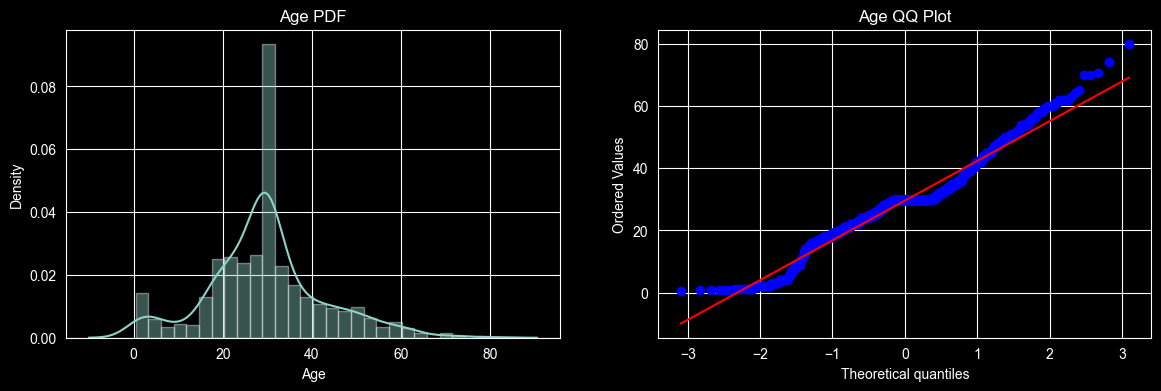

In [16]:
plt.figure(figsize = (14, 4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

plt.show()

C:\Users\rohit\AppData\Local\Temp\ipykernel_10000\2638396426.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


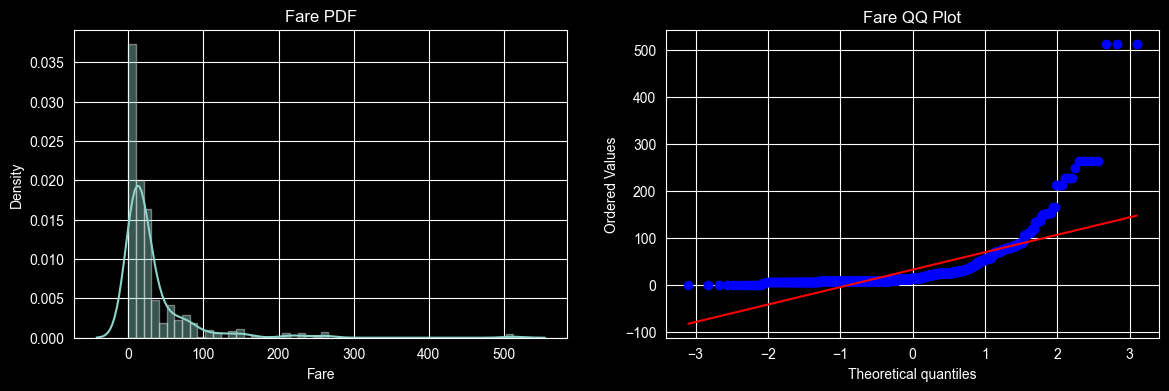

In [17]:
plt.figure(figsize = (14, 4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [18]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [19]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR : ", accuracy_score(y_test, y_pred))
print("Accuracy DT : ", accuracy_score(y_test, y_pred1))

Accuracy LR :  0.6480446927374302
Accuracy DT :  0.6536312849162011


In [20]:
trf = FunctionTransformer(func=np.log1p)

In [21]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [22]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [23]:
clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR : ", accuracy_score(y_test, y_pred))
print("Accuracy DT : ", accuracy_score(y_test, y_pred1))

Accuracy LR :  0.6815642458100558
Accuracy DT :  0.6927374301675978


In [24]:
X_transfomed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transfomed, y, cv=10, scoring='accuracy')))
print("DT", np.mean(cross_val_score(clf2, X_transfomed, y, cv=10, scoring='accuracy')))

LR 0.678027465667915
DT 0.6621972534332085


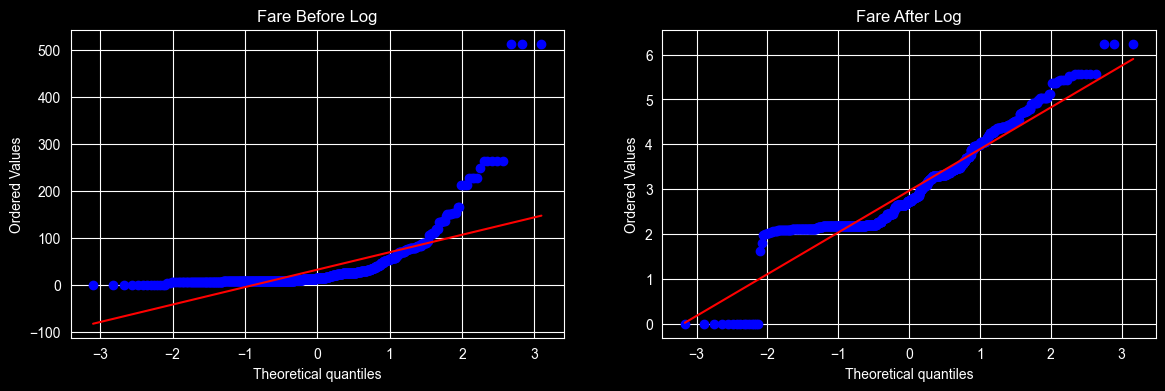

In [25]:
plt.figure(figsize = (14, 4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title("Fare Before Log")

plt.subplot(122)
stats.probplot(X_transfomed['Fare'], dist='norm', plot=plt)
plt.title("Fare After Log")

plt.show()

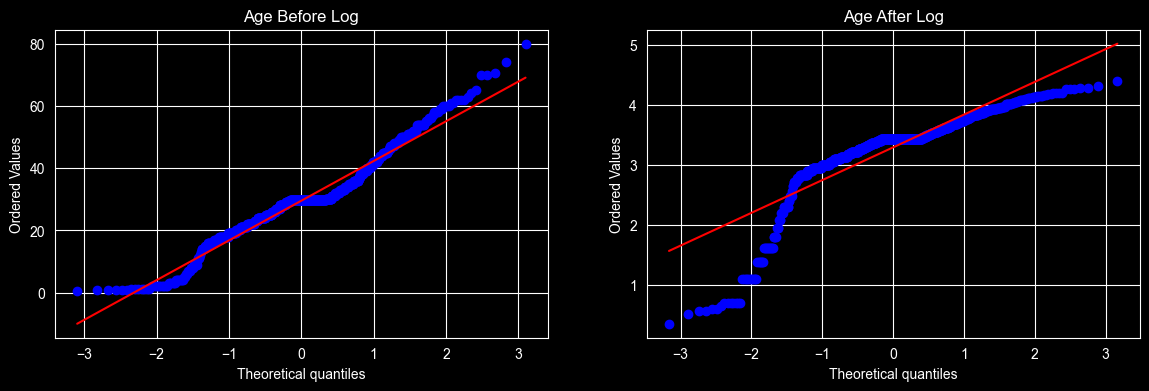

In [26]:
plt.figure(figsize = (14, 4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title("Age Before Log")

plt.subplot(122)
stats.probplot(X_transfomed['Age'], dist='norm', plot=plt)
plt.title("Age After Log")

plt.show()

In [27]:
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [28]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred1 = clf2.predict(X_test_transformed2)

print("Accuracy LR : ", accuracy_score(y_test, y_pred))
print("Accuracy DT : ", accuracy_score(y_test, y_pred1))

Accuracy LR :  0.6703910614525139
Accuracy DT :  0.6703910614525139


In [29]:
X_transfomed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transfomed2, y, cv=10, scoring='accuracy')))
print("DT", np.mean(cross_val_score(clf2, X_transfomed2, y, cv=10, scoring='accuracy')))

LR 0.6712609238451936
DT 0.6599500624219725


In [35]:
def apply_transform(transform):
    X = df.iloc[:, 1:3]
    y = df.iloc[:, 0]

    trf = ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])], remainder='passthrough')

    X_trans = trf.fit_transform(X)
    clf = LogisticRegression()

    print("Accuracy : ", np.mean(cross_val_score(clf, X_trans, y, cv=10, scoring='accuracy')))

    plt.figure(figsize = (14, 4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist='norm', plot=plt)
    plt.title("Fare Before Transform")

    plt.subplot(122)
    stats.probplot(X_trans[:, 0], dist='norm', plot=plt)
    plt.title("Fare After Transform")

    plt.show()

Accuracy :  0.6589013732833957


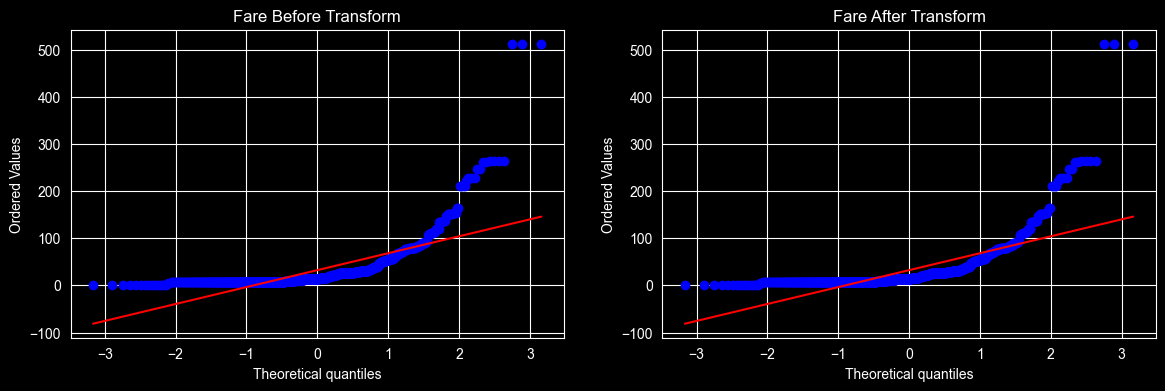

In [36]:
apply_transform(lambda x : x)

Accuracy :  0.6431335830212235


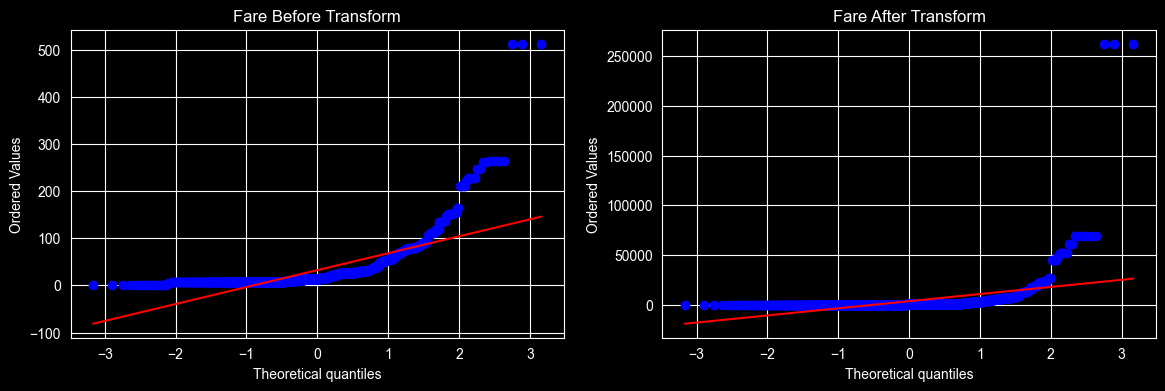

In [37]:
apply_transform(lambda x : x**2)

Accuracy :  0.6589013732833957


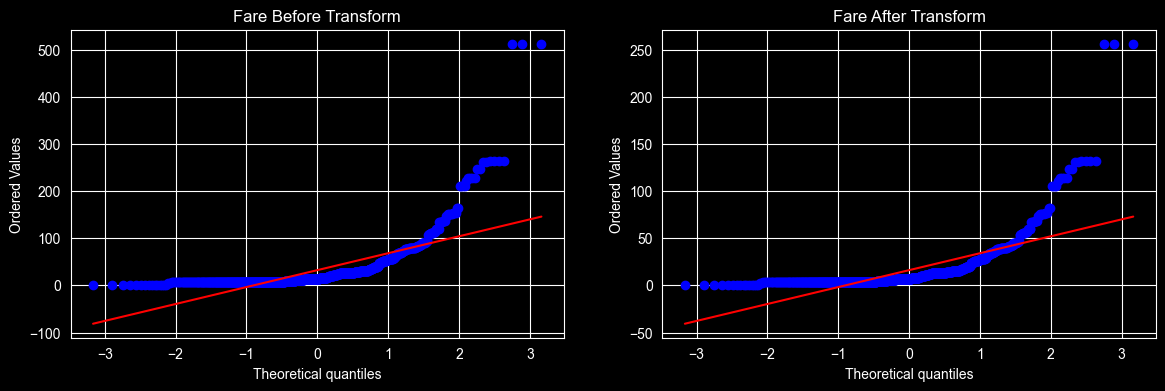

In [38]:
apply_transform(lambda x : x**1/2)

Accuracy :  0.61729088639201


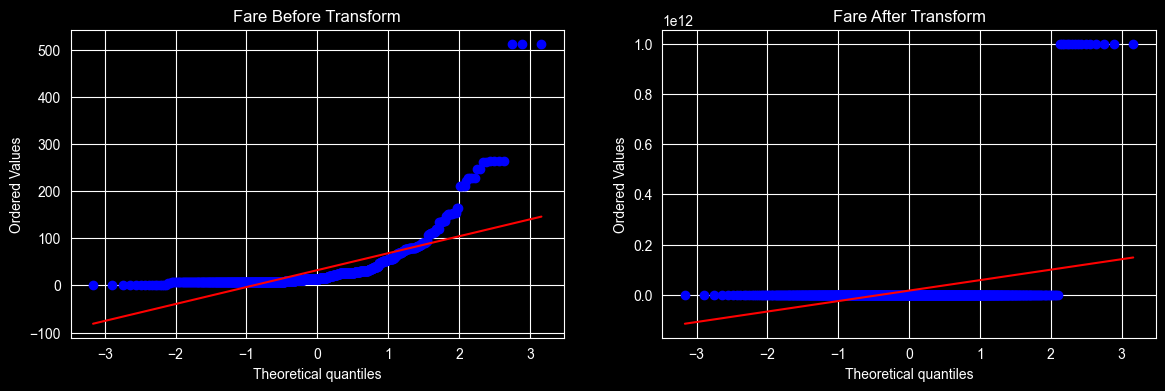

In [41]:
apply_transform(lambda x : 1/(x+0.000000000001))